# W01 · Deep Learning Foundations

## Neural Networks for Regression and Classification

Deep learning is introduced through two complete neural-network problems:

1. **Regression** — predicting a continuous numeric value.
2. **Classification** — predicting a class.

The emphasis is placed on four ideas:

- what a neuron computes,
- why hidden layers are useful,
- how a neural network changes between regression and classification,
- how model outputs are evaluated and interpreted.

**Ahmed Métwalli**

## Learning Outcomes

By the end of this notebook, you should be able to:

- distinguish classical machine learning from deep learning at a conceptual level;
- explain the computation performed by one artificial neuron;
- identify the input, hidden, and output layers of a neural network;
- formulate a simple regression problem for a neural network;
- formulate a simple binary-classification problem for a neural network;
- interpret MAE, $R^2$, accuracy, precision, recall, a confusion matrix, and a decision boundary;
- explain why a neural network can represent nonlinear relationships that a simple linear model cannot.

# 1. From Classical Machine Learning to Deep Learning

Classical machine-learning methods remain highly effective, especially for structured tabular data.  
Deep learning becomes particularly useful when the relationship between the input and the required output is difficult to describe with a small set of manually designed rules or features.

A useful way to compare the two approaches is:

| Classical machine learning | Deep learning |
|---|---|
| Often relies strongly on prepared features | Can learn useful intermediate representations |
| Frequently uses one main transformation or decision rule | Stacks several learnable transformations |
| Excellent for many structured-data problems | Particularly powerful for complex nonlinear and high-dimensional data |
| Usually easier to inspect and train | Can represent much more complicated functions |

A neural network learns a sequence of transformations:

**Input features → hidden representation → deeper representation → prediction**

The hidden layers progressively reshape the information so that the final output becomes easier to produce.

> **Important:** Deep learning does not replace classical machine learning.  
> It extends the modeling toolbox when the problem requires richer nonlinear representations.

The two-feature examples in this notebook make every step visible. The same principles later extend to images, audio, text, signals, and other high-dimensional data.

# 2. One Artificial Neuron

A neuron receives several inputs, assigns a trainable weight to each input, adds a trainable bias, and then applies an activation function.

The weighted sum is

$$
z = \sum_{j=1}^{d} w_j x_j + b
$$

For two input features,

$$
z = w_1x_1 + w_2x_2 + b
$$

The neuron output is

$$
a = g(z)
$$

where:

- $x_j$ is the $j$-th input feature;
- $w_j$ is the trainable weight associated with $x_j$;
- $b$ is the trainable bias;
- $z$ is the weighted sum before activation;
- $g(\cdot)$ is the activation function;
- $a$ is the neuron output.

### Numerical example

Suppose

$$
x_1=2,\qquad x_2=3,\qquad
w_1=0.5,\qquad w_2=-0.2,\qquad b=0.1
$$

Then

$$
z=(0.5)(2)+(-0.2)(3)+0.1
$$

$$
z=1-0.6+0.1=0.5
$$

If the activation function is ReLU,

$$
\operatorname{ReLU}(z)=\max(0,z)
$$

therefore

$$
a=\operatorname{ReLU}(0.5)=0.5
$$

A neural network is created by connecting many such neurons in layers.

### Required Concept Check 1

Answer before continuing:

1. What is the role of a weight?
2. What is the role of the bias?
3. What does an activation function add that a purely linear weighted sum does not?
4. Using the numerical example above, what would the neuron output be if $z=-0.7$ and ReLU were used?

In [1]:
# Core imports and reproducibility
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from sklearn.datasets import make_moons

SEED = 2026
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print("Environment ready.")

Environment ready.


In [2]:
def draw_network(layer_sizes, layer_labels, title, output_note=None):
    """Draw a clean feed-forward neural network with directional connections."""
    fig, ax = plt.subplots(figsize=(10, 5.2))
    ax.set_title(title, fontsize=16, weight="bold", pad=18)
    ax.axis("off")

    xs = np.linspace(0.10, 0.90, len(layer_sizes))
    layer_positions = []

    for n in layer_sizes:
        if n == 1:
            ys = np.array([0.5])
        else:
            ys = np.linspace(0.20, 0.80, n)
        layer_positions.append(ys)

    # Connections first
    for i in range(len(layer_sizes) - 1):
        x1, x2 = xs[i], xs[i + 1]
        for y1 in layer_positions[i]:
            for y2 in layer_positions[i + 1]:
                ax.annotate(
                    "",
                    xy=(x2 - 0.028, y2),
                    xytext=(x1 + 0.028, y1),
                    arrowprops=dict(
                        arrowstyle="->",
                        lw=0.9,
                        alpha=0.24,
                        shrinkA=0,
                        shrinkB=0,
                    ),
                )

    # Nodes and labels
    for i, (x, ys) in enumerate(zip(xs, layer_positions)):
        for y in ys:
            node = plt.Circle(
                (x, y),
                0.028,
                facecolor="white",
                edgecolor="black",
                linewidth=1.8,
                zorder=3,
            )
            ax.add_patch(node)

        ax.text(
            x,
            0.09,
            layer_labels[i],
            ha="center",
            va="center",
            fontsize=11,
            weight="bold",
        )

    if output_note:
        ax.text(
            0.90,
            0.88,
            output_note,
            ha="center",
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="black"),
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.show()

# 3. Problem 1 — Neural-Network Regression

## Real-Life Problem: Delivery-Time Prediction

A local delivery company records two quantities for each trip:

- **distance** in kilometers;
- **traffic level** on a scale from 0 to 10.

The required output is:

- **delivery time** in minutes.

Because the target is a continuous numeric quantity, the task is a **regression problem**.

$$
(\text{distance},\ \text{traffic})
\longrightarrow
\text{delivery time}
$$

A simple linear relationship may be insufficient because the influence of traffic can become more severe on longer trips.  
That interaction creates a nonlinear relationship that a small neural network can learn.

In [3]:
# Generate a small, interpretable regression dataset
n = 180

distance_km = rng.uniform(1, 20, n)
traffic_level = rng.uniform(0, 10, n)

delivery_time = (
    7
    + 2.4 * distance_km
    + 1.7 * traffic_level
    + 0.16 * distance_km * traffic_level
    + rng.normal(0, 3.0, n)
)

reg_df = pd.DataFrame({
    "distance_km": distance_km,
    "traffic_level": traffic_level,
    "delivery_time_min": delivery_time,
})

reg_df.head()

,distance_km,traffic_level,delivery_time_min
0,4.399761,7.178344,36.149953
1,13.158350,7.187932,67.220114
2,9.878100,8.505513,57.626205
3,8.039510,9.796258,54.868129
4,7.743429,2.754809,36.177300


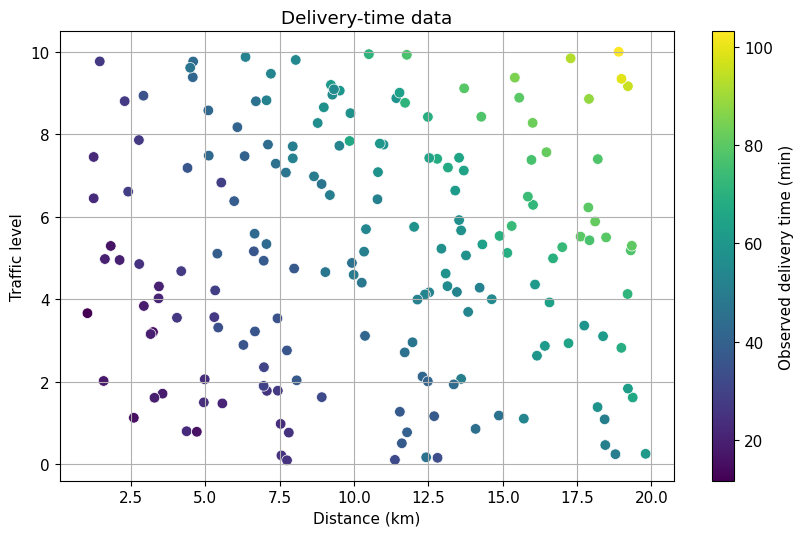

In [4]:
# Visualize the regression problem
fig, ax = plt.subplots(figsize=(8.5, 5.5))

scatter = ax.scatter(
    reg_df["distance_km"],
    reg_df["traffic_level"],
    c=reg_df["delivery_time_min"],
    s=58,
    edgecolor="white",
    linewidth=0.5,
)

ax.set_title("Delivery-time data")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Traffic level")

cb = plt.colorbar(scatter, ax=ax)
cb.set_label("Observed delivery time (min)")

plt.tight_layout()
plt.show()

## Regression Network

For regression, the network produces one unrestricted numeric output.

The model can be written abstractly as

$$
\hat{y}=f_{\theta}(x_1,x_2)
$$

where:

- $x_1$ is distance;
- $x_2$ is traffic level;
- $\hat{y}$ is the predicted delivery time;
- $\theta$ represents all trainable weights and biases.

The network used below has:

- 2 input features;
- 8 neurons in the first hidden layer;
- 4 neurons in the second hidden layer;
- 1 output neuron for the predicted time.

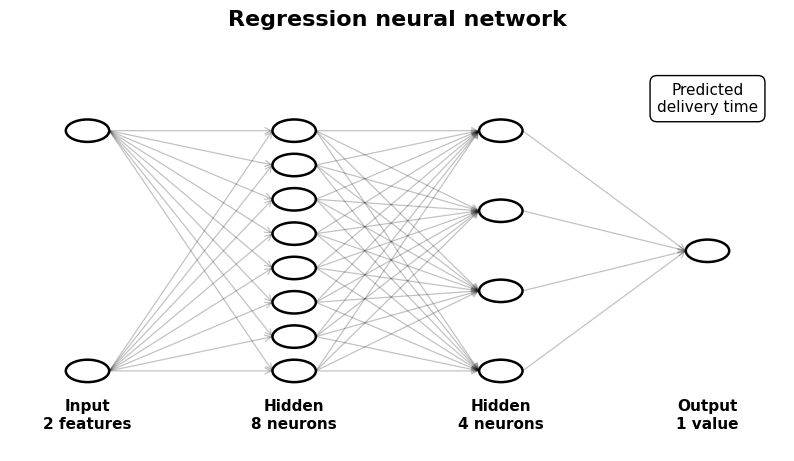

In [5]:
draw_network(
    [2, 8, 4, 1],
    ["Input\n2 features", "Hidden\n8 neurons", "Hidden\n4 neurons", "Output\n1 value"],
    "Regression neural network",
    output_note="Predicted\ndelivery time",
)

## Regression Loss and Evaluation

A common training loss for regression is Mean Squared Error:

$$
\operatorname{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(y_i-\hat{y}_i\right)^2
$$

The squared term gives larger errors a stronger penalty.

For interpretation, Mean Absolute Error is also useful:

$$
\operatorname{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|y_i-\hat{y}_i\right|
$$

If $\operatorname{MAE}=3.0$ minutes, the predictions differ from the true delivery times by about 3 minutes on average.

The coefficient of determination is

$$
R^2
=
1-
\frac{
\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{N}(y_i-\bar{y})^2
}
$$

Values closer to $1$ indicate that more of the target variation is explained by the model.

In [6]:
# Split the data so evaluation is performed on unseen examples
X_reg = reg_df[["distance_km", "traffic_level"]]
y_reg = reg_df["delivery_time_min"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=SEED,
)

# Linear baseline
linear_regression = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

# Neural network
nn_regression = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(8, 4),
        activation="relu",
        solver="adam",
        learning_rate_init=0.01,
        max_iter=2500,
        random_state=SEED,
    )),
])

linear_regression.fit(X_train_reg, y_train_reg)
nn_regression.fit(X_train_reg, y_train_reg)

pred_linear = linear_regression.predict(X_test_reg)
pred_nn = nn_regression.predict(X_test_reg)

reg_results = pd.DataFrame({
    "Model": ["Linear regression", "Neural network"],
    "MAE (min)": [
        mean_absolute_error(y_test_reg, pred_linear),
        mean_absolute_error(y_test_reg, pred_nn),
    ],
    "MSE": [
        mean_squared_error(y_test_reg, pred_linear),
        mean_squared_error(y_test_reg, pred_nn),
    ],
    "R²": [
        r2_score(y_test_reg, pred_linear),
        r2_score(y_test_reg, pred_nn),
    ],
})

reg_results.round(3)

,Model,MAE (min),MSE,R²
0,Linear regression,2.918,14.205,0.965
1,Neural network,2.692,11.693,0.971


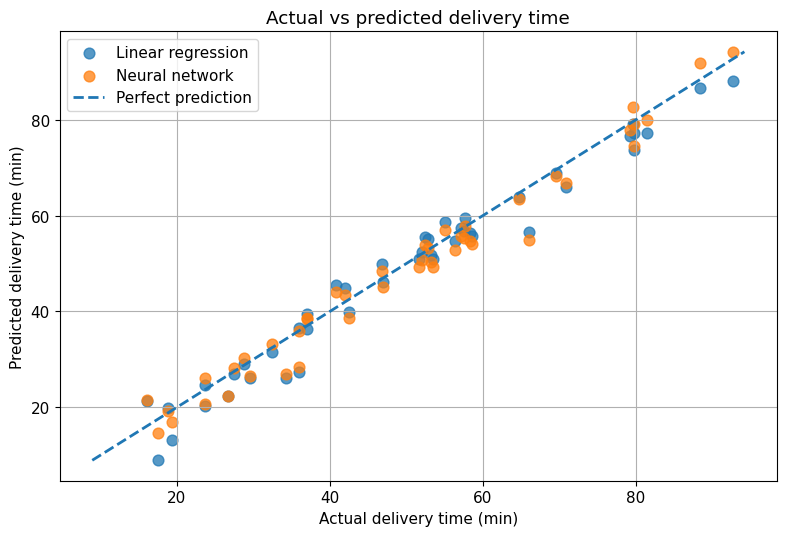

In [7]:
# Predicted vs actual delivery time
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(
    y_test_reg,
    pred_linear,
    alpha=0.75,
    s=60,
    label="Linear regression",
)

ax.scatter(
    y_test_reg,
    pred_nn,
    alpha=0.75,
    s=60,
    label="Neural network",
)

low = min(y_test_reg.min(), pred_linear.min(), pred_nn.min())
high = max(y_test_reg.max(), pred_linear.max(), pred_nn.max())

ax.plot(
    [low, high],
    [low, high],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction",
)

ax.set_title("Actual vs predicted delivery time")
ax.set_xlabel("Actual delivery time (min)")
ax.set_ylabel("Predicted delivery time (min)")
ax.legend()

plt.tight_layout()
plt.show()

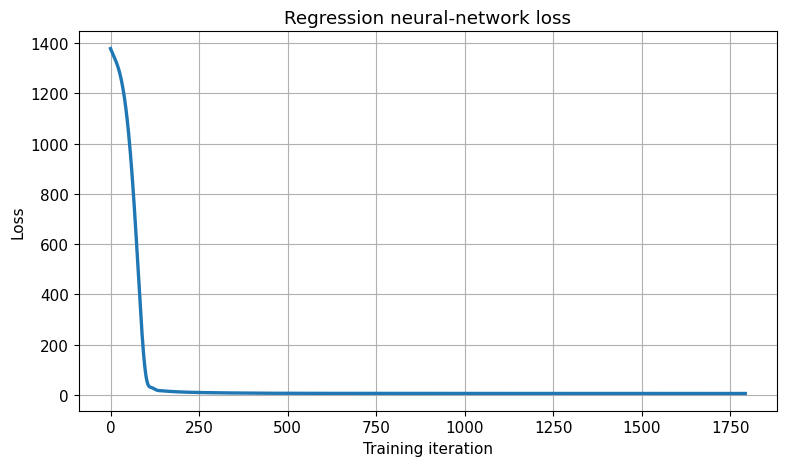

In [8]:
# Neural-network training loss
nn_reg_model = nn_regression.named_steps["model"]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(nn_reg_model.loss_curve_, linewidth=2.4)

ax.set_title("Regression neural-network loss")
ax.set_xlabel("Training iteration")
ax.set_ylabel("Loss")

plt.tight_layout()
plt.show()

### How to Read the Regression Results

- A **smaller MAE** means the predicted delivery times are closer to the true times.
- A **larger $R^2$** indicates that more of the variation in delivery time is captured by the model.
- In the actual-vs-predicted plot, points closer to the dashed diagonal are better predictions.
- A falling training-loss curve shows that the network is improving its fit to the training data.
- A lower training loss alone is not sufficient. Performance must also be checked on unseen test data.

## Required Practice A — Regression

Complete this practice during the section.

### Task

The baseline neural network uses hidden layers `(8, 4)`.

1. Run the practice cell below with `(4,)`.
2. Record the test MAE and $R^2$.
3. Change the architecture to `(16, 8)`.
4. Run the cell again.
5. Compare both results with the original `(8, 4)` network.
6. State which architecture performed best on the **test set**, not the training set.

### Interpretation Questions

- Did adding more neurons always improve the test result?
- Why can a larger neural network sometimes perform worse?
- Which metric is easiest to explain to a delivery manager: MAE or MSE? Why?

In [9]:
# REQUIRED PRACTICE A
# Run once with (4,), record the results, then change to (16, 8) and run again.

practice_reg_architecture = (4,)   # Change this to (16, 8) for the second run.

practice_regression = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=practice_reg_architecture,
        activation="relu",
        solver="adam",
        learning_rate_init=0.01,
        max_iter=2500,
        random_state=SEED,
    )),
])

practice_regression.fit(X_train_reg, y_train_reg)
practice_pred_reg = practice_regression.predict(X_test_reg)

practice_mae = mean_absolute_error(y_test_reg, practice_pred_reg)
practice_r2 = r2_score(y_test_reg, practice_pred_reg)

print("Architecture:", practice_reg_architecture)
print(f"Test MAE: {practice_mae:.3f} min")
print(f"Test R²:  {practice_r2:.3f}")

Architecture: (4,)
Test MAE: 2.813 min
Test R²:  0.968


# 4. Problem 2 — Neural-Network Classification

## Real-Life Problem: Automated Quality Inspection

A production line records two sensor measurements for every manufactured item:

- **Sensor A**
- **Sensor B**

The required output is one of two classes:

- class $0$: normal;
- class $1$: requires inspection.

Because the target is a discrete category, the task is **binary classification**.

$$
(\text{Sensor A},\ \text{Sensor B})
\longrightarrow
\{\text{normal},\ \text{requires inspection}\}
$$

The two classes form a curved pattern. A straight decision boundary cannot represent that structure well, so hidden nonlinear transformations become useful.

In [10]:
# Nonlinear binary-classification dataset
X_cls, y_cls = make_moons(
    n_samples=300,
    noise=0.22,
    random_state=SEED,
)

cls_df = pd.DataFrame({
    "sensor_A": X_cls[:, 0],
    "sensor_B": X_cls[:, 1],
    "requires_inspection": y_cls,
})

cls_df.head()

,sensor_A,sensor_B,requires_inspection
0,0.746933,-0.345339,1
1,0.634687,-0.323167,1
2,1.152196,-0.383847,1
3,-0.866210,0.183746,0
4,-0.554063,0.117851,0


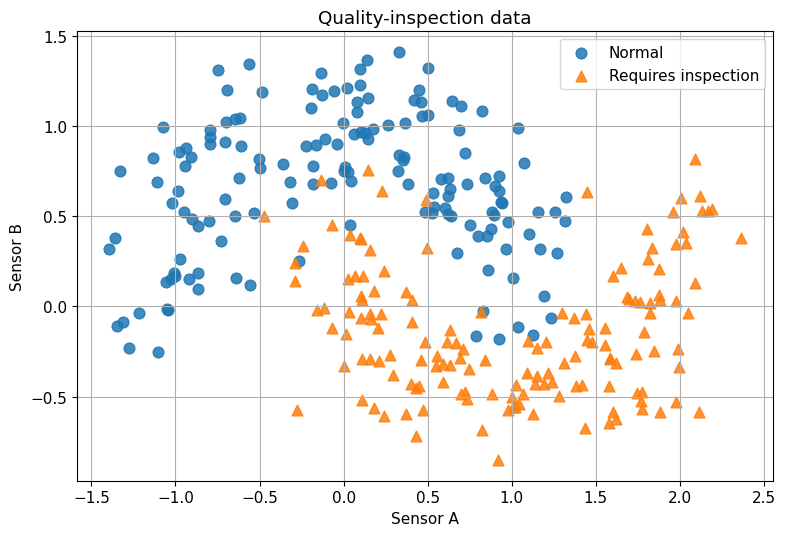

In [11]:
# Visualize the two classes
fig, ax = plt.subplots(figsize=(8, 5.5))

for label, marker, name in [
    (0, "o", "Normal"),
    (1, "^", "Requires inspection"),
]:
    subset = cls_df[cls_df["requires_inspection"] == label]
    ax.scatter(
        subset["sensor_A"],
        subset["sensor_B"],
        s=60,
        marker=marker,
        alpha=0.85,
        label=name,
    )

ax.set_title("Quality-inspection data")
ax.set_xlabel("Sensor A")
ax.set_ylabel("Sensor B")
ax.legend()

plt.tight_layout()
plt.show()

## Classification Network

The hidden layers may have the same structure as the regression network, but the meaning of the output changes.

For binary classification, the final output represents the estimated probability of class $1$:

$$
\hat{p}
=
P(y=1\mid x_1,x_2)
$$

The predicted class can be obtained using a threshold:

$$
\hat{y}
=
\begin{cases}
1, & \hat{p}\ge 0.5 \\[4pt]
0, & \hat{p}<0.5
\end{cases}
$$

The classification network below therefore ends with **one probability output**, rather than an unrestricted numeric regression output.

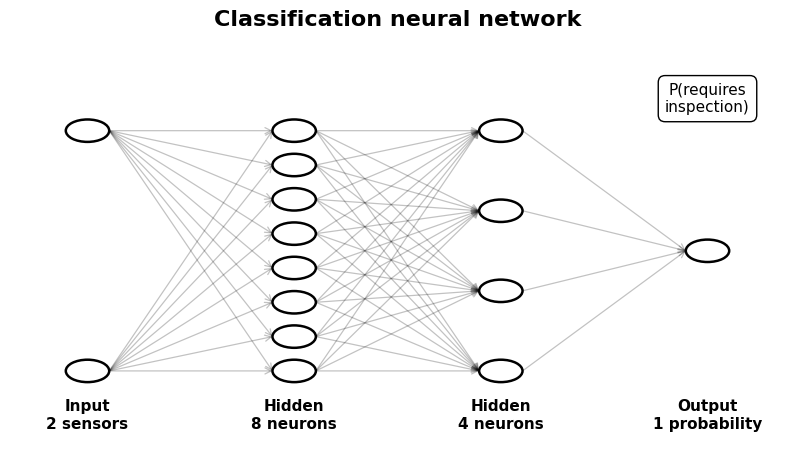

In [12]:
draw_network(
    [2, 8, 4, 1],
    ["Input\n2 sensors", "Hidden\n8 neurons", "Hidden\n4 neurons", "Output\n1 probability"],
    "Classification neural network",
    output_note="P(requires\ninspection)",
)

## Binary Cross-Entropy

A common loss for binary classification is Binary Cross-Entropy:

$$
\operatorname{BCE}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
$$

where:

- $y_i\in\{0,1\}$ is the true class;
- $\hat{p}_i$ is the predicted probability of class $1$.

A confident correct prediction gives a small penalty.  
A confident incorrect prediction gives a much larger penalty.

In [13]:
# Train/test split
X_cls_df = cls_df[["sensor_A", "sensor_B"]]
y_cls_s = cls_df["requires_inspection"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_df,
    y_cls_s,
    test_size=0.25,
    random_state=SEED,
    stratify=y_cls_s,
)

# Straight-boundary baseline
logistic_classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression()),
])

# Nonlinear neural network
nn_classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(8, 4),
        activation="relu",
        solver="adam",
        learning_rate_init=0.01,
        max_iter=2500,
        random_state=SEED,
    )),
])

logistic_classifier.fit(X_train_cls, y_train_cls)
nn_classifier.fit(X_train_cls, y_train_cls)

pred_logistic = logistic_classifier.predict(X_test_cls)
pred_nn_cls = nn_classifier.predict(X_test_cls)

cls_results = pd.DataFrame({
    "Model": ["Logistic regression", "Neural network"],
    "Accuracy": [
        accuracy_score(y_test_cls, pred_logistic),
        accuracy_score(y_test_cls, pred_nn_cls),
    ],
    "Precision": [
        precision_score(y_test_cls, pred_logistic),
        precision_score(y_test_cls, pred_nn_cls),
    ],
    "Recall": [
        recall_score(y_test_cls, pred_logistic),
        recall_score(y_test_cls, pred_nn_cls),
    ],
})

cls_results.round(3)

,Model,Accuracy,Precision,Recall
0,Logistic regression,0.880,0.872,0.895
1,Neural network,0.947,0.925,0.974


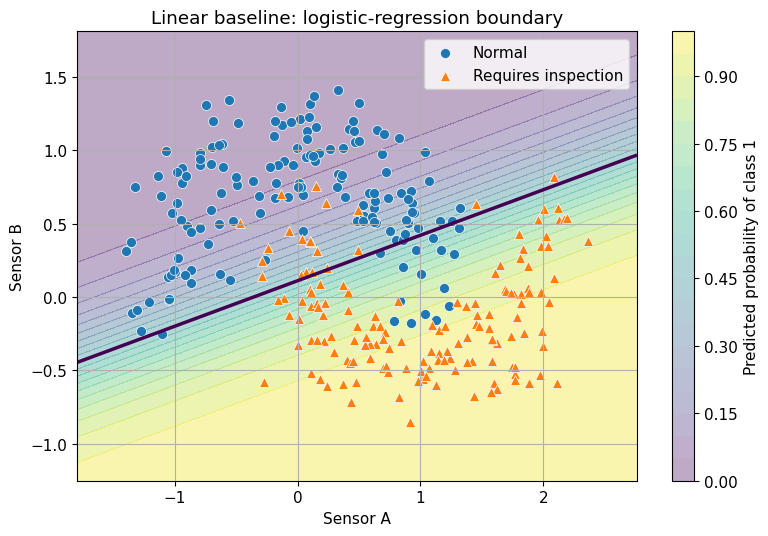

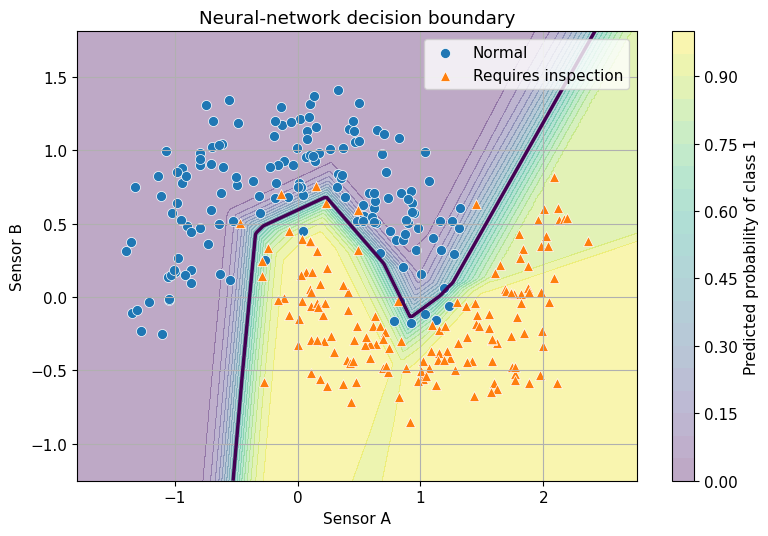

In [14]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X.iloc[:, 0].min() - 0.4, X.iloc[:, 0].max() + 0.4
    y_min, y_max = X.iloc[:, 1].min() - 0.4, X.iloc[:, 1].max() + 0.4

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )

    grid = pd.DataFrame({
        X.columns[0]: xx.ravel(),
        X.columns[1]: yy.ravel(),
    })

    probability = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    contour = ax.contourf(
        xx,
        yy,
        probability,
        levels=np.linspace(0, 1, 21),
        alpha=0.35,
    )

    ax.contour(
        xx,
        yy,
        probability,
        levels=[0.5],
        linewidths=2.5,
    )

    for label, marker, name in [
        (0, "o", "Normal"),
        (1, "^", "Requires inspection"),
    ]:
        subset = X[y == label]
        ax.scatter(
            subset.iloc[:, 0],
            subset.iloc[:, 1],
            s=52,
            marker=marker,
            edgecolor="white",
            linewidth=0.5,
            label=name,
        )

    ax.set_title(title)
    ax.set_xlabel("Sensor A")
    ax.set_ylabel("Sensor B")
    ax.legend()

    cb = plt.colorbar(contour, ax=ax)
    cb.set_label("Predicted probability of class 1")

    plt.tight_layout()
    plt.show()


plot_decision_boundary(
    logistic_classifier,
    X_cls_df,
    y_cls_s,
    "Linear baseline: logistic-regression boundary",
)

plot_decision_boundary(
    nn_classifier,
    X_cls_df,
    y_cls_s,
    "Neural-network decision boundary",
)

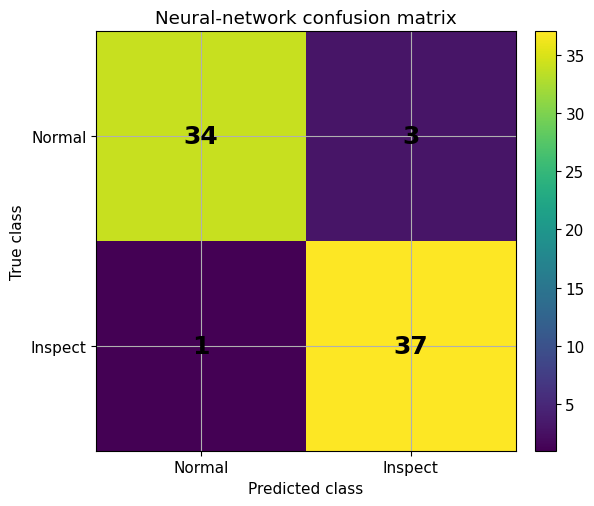

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test_cls, pred_nn_cls)

fig, ax = plt.subplots(figsize=(6, 5.2))
im = ax.imshow(cm)

ax.set_title("Neural-network confusion matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks([0, 1], ["Normal", "Inspect"])
ax.set_yticks([0, 1], ["Normal", "Inspect"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=18,
            weight="bold",
        )

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

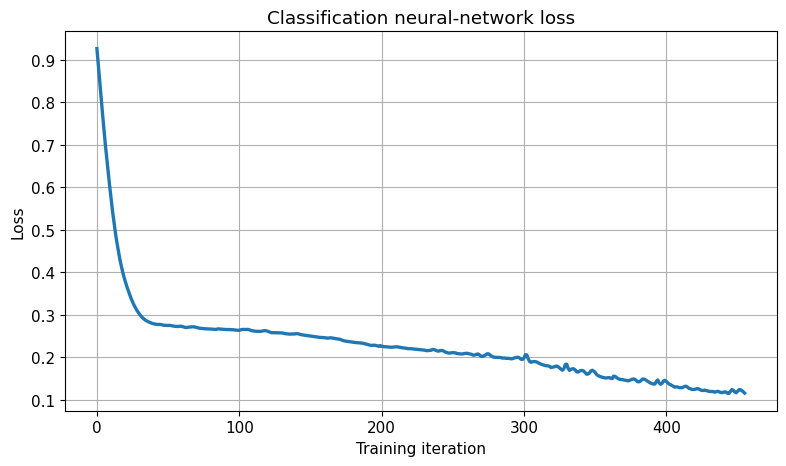

In [16]:
# Classification training loss
nn_cls_model = nn_classifier.named_steps["model"]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(nn_cls_model.loss_curve_, linewidth=2.4)

ax.set_title("Classification neural-network loss")
ax.set_xlabel("Training iteration")
ax.set_ylabel("Loss")

plt.tight_layout()
plt.show()

### How to Read the Classification Results

Accuracy:

$$
\operatorname{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}
$$

Precision:

$$
\operatorname{Precision}
=
\frac{TP}{TP+FP}
$$

Recall:

$$
\operatorname{Recall}
=
\frac{TP}{TP+FN}
$$

Interpretation:

- **Accuracy** measures the overall fraction of correct predictions.
- **Precision** asks: when the model predicts “requires inspection,” how often is that prediction correct?
- **Recall** asks: among all items that truly require inspection, how many are detected?
- The **decision boundary** shows where the predicted class changes.
- The **confusion matrix** shows the exact pattern of correct predictions and mistakes.

For a safety-critical inspection process, recall can become particularly important because a false negative means that an item requiring inspection was missed.

## Required Practice B — Classification

Complete this practice during the section.

### Task

1. Run the practice cell with the architecture `(4,)`.
2. Record accuracy, precision, and recall.
3. Change the architecture to `(16, 8)`.
4. Run the cell again.
5. Compare both models with the original `(8, 4)` network.
6. Identify whether any improvement is consistent across **all three metrics**.

### Interpretation Questions

- Did the larger network always improve accuracy?
- If recall improves but precision decreases, what practical trade-off has occurred?
- Why is a curved decision boundary useful for this dataset?
- Why should the final conclusion be based on test data rather than training performance?

In [17]:
# REQUIRED PRACTICE B
# Run once with (4,), record the metrics, then change to (16, 8) and run again.

practice_cls_architecture = (4,)   # Change this to (16, 8) for the second run.

practice_classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=practice_cls_architecture,
        activation="relu",
        solver="adam",
        learning_rate_init=0.01,
        max_iter=2500,
        random_state=SEED,
    )),
])

practice_classifier.fit(X_train_cls, y_train_cls)
practice_pred_cls = practice_classifier.predict(X_test_cls)

print("Architecture:", practice_cls_architecture)
print(f"Accuracy:  {accuracy_score(y_test_cls, practice_pred_cls):.3f}")
print(f"Precision: {precision_score(y_test_cls, practice_pred_cls):.3f}")
print(f"Recall:    {recall_score(y_test_cls, practice_pred_cls):.3f}")

Architecture: (4,)
Accuracy:  0.907
Precision: 0.860
Recall:    0.974


# 5. Regression vs Classification — What Changes?

| Element | Regression | Binary Classification |
|---|---|---|
| Target | Continuous number | Class $0$ or $1$ |
| Example | Delivery time | Inspection decision |
| Network input | Features | Features |
| Hidden layers | Learn nonlinear representations | Learn nonlinear representations |
| Final output | Numeric prediction | Probability / class |
| Typical loss | MSE | Binary cross-entropy |
| Typical metrics | MAE, MSE, $R^2$ | Accuracy, precision, recall |

The central structure of the neural network remains similar.  
The **problem definition, output interpretation, loss function, and evaluation metrics** change according to the task.

# 6. Required Final Concept Check

Answer all questions.

1. Why is deep learning considered part of machine learning rather than a separate field?
2. Why can hidden layers help with nonlinear relationships?
3. In the regression example, what does one output neuron represent?
4. In the classification example, what does one output neuron represent?
5. Why is the same evaluation metric not used for both problems?
6. What does a falling training-loss curve tell us, and what does it **not** guarantee?
7. Why is unseen test data necessary?
8. Give one real problem that should be formulated as regression.
9. Give one real problem that should be formulated as classification.
10. State one situation in which a simpler classical machine-learning model may be preferable to a neural network.